# The floruit field

In [1]:
import duckdb
import matplotlib.pyplot as plt
import polars as pl
from style import *

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CV_PATH = '../data/similar_databases/cross_verified.duckdb'

FIRST_CENTURY = -1000
LAST_CENTURY = 2000
PRECISION_ORDER = ['day', 'month', 'year', 'decade']
PRECISION_COLORS = {'day': NAVY, 'month': DARK_BLUE, 'year': BLUE, 'decade': LIGHT_BLUE}
MID_DECADE = 5

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(80)

apply_style()

connection = duckdb.connect(DB_PATH, read_only=True)
connection.execute(f"ATTACH '{CV_PATH}' AS cv (READ_ONLY)")

## Format

In [2]:
connection.execute('''
    SELECT count(*) AS individuals,
           count(*) FILTER (WHERE len(floruit_date) > 0) AS with_floruit,
           max(len(floruit_date)) AS most_entries_on_one_individual
    FROM individual
''').pl()

individuals,with_floruit,most_entries_on_one_individual
i64,i64,i64
13002897,70521,1


In [3]:
connection.execute('''
    SELECT individual.entity.label_en AS name, individual.entity.description,
           floruit_date[1].iso AS iso, floruit_date[1].year AS year, floruit_date[1].precision AS precision,
           floruit_date[1].field_provenance['year'].raw AS provenance_raw
    FROM individual
    WHERE len(floruit_date) > 0
    ORDER BY hash(individual.entity.qid)
    LIMIT 8
''').pl()

name,description,iso,year,precision,provenance_raw
str,str,str,i64,str,list[str]
"""Florentius""",null,"""0300-01-01""",300,"""century""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
null,null,"""1177-01-01""",1177,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Ingela M Grumme""",null,"""2014-01-01""",2014,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Rein van Houts""",null,"""1945-01-01""",1945,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Walter G. Joyce""","""American/Swiss paleontologist""","""2015-01-01""",2015,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Hillary Joy Kipnis""",null,"""1987-01-01""",1987,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""T. Chaduk""","""voice actor (fl. in the 1930s)""","""1930-01-01""",1930,"""decade""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Johannes von Magdeburg""",null,"""1250-01-01""",1250,"""century""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"


## Load the floruit individuals

In [4]:
floruit = connection.execute('''
    SELECT individual.entity.qid AS qid,
           floruit_date[1].year AS year,
           coalesce(floruit_date[1].precision, 'unknown') AS precision,
           CASE WHEN floruit_date[1].field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates'
                THEN 'Wikipedia article' ELSE 'Wikidata P1317' END AS source,
           len(birth_date) > 0 AS has_birth,
           len(death_date) > 0 AS has_death,
           coalesce(cv.level1_main_occ, 'Not in CV') AS category,
           coalesce(birth_country.present_day_state.continent,
                    death_country.present_day_state.continent,
                    citizenship.present_day_state.continent,
                    'No location') AS region
    FROM individual
    LEFT JOIN cv.individuals AS cv ON cv.wikidata_code = individual.entity.qid
    LEFT JOIN place AS birthplace ON birthplace.entity.qid = individual.place_of_birth.entity.qid
    LEFT JOIN place AS birth_country ON birth_country.entity.qid = birthplace.country.qid
    LEFT JOIN place AS deathplace ON deathplace.entity.qid = individual.place_of_death.entity.qid
    LEFT JOIN place AS death_country ON death_country.entity.qid = deathplace.country.qid
    LEFT JOIN place AS citizenship ON citizenship.entity.qid = individual.country_of_citizenship[1].entity.qid
    WHERE len(floruit_date) > 0
''').pl()

print(f'{len(floruit):,} individuals with a floruit')

70,521 individuals with a floruit


## Source and precision

In [5]:
floruit.group_by('source', 'precision').len().sort('source', 'len', descending=[False, True])

source,precision,len
str,str,u32
"""Wikidata P1317""","""year""",52006
"""Wikidata P1317""","""century""",12637
"""Wikidata P1317""","""decade""",2429
"""Wikidata P1317""","""day""",1051
"""Wikidata P1317""","""month""",349
"""Wikidata P1317""","""millennium""",166
"""Wikidata P1317""","""unknown""",3
"""Wikipedia article""","""year""",1880


## Keep the year-level floruits only

In [6]:
dropped = floruit.filter(~pl.col('precision').is_in(PRECISION_ORDER))
floruit = (
    floruit.filter(pl.col('precision').is_in(PRECISION_ORDER))
    .with_columns(pl.when(pl.col('precision') == 'decade').then(pl.col('year') + MID_DECADE).otherwise(pl.col('year')).alias('year'))
    .with_columns((pl.col('year') // 100 * 100).alias('century_start'))
)
print(f'{len(floruit):,} year-level floruits kept, {len(dropped):,} left out:')
dropped.group_by('precision').len().sort('len', descending=True)

57,715 year-level floruits kept, 12,806 left out:


precision,len
str,u32
"""century""",12637
"""millennium""",166
"""unknown""",3


## Other dates beside the floruit

In [7]:
floruit.group_by('has_birth', 'has_death').len().sort('len', descending=True).with_columns(
    (pl.col('len') / pl.col('len').sum() * 100).round(1).alias('percent')
)

has_birth,has_death,len,percent
bool,bool,u32,f64
false,false,37446,64.9
true,true,10023,17.4
true,false,9222,16.0
false,true,1024,1.8


## By century

82 individuals before -1000 left out of the chart
15 individuals with a floruit after 2099 — data errors — left out of the chart


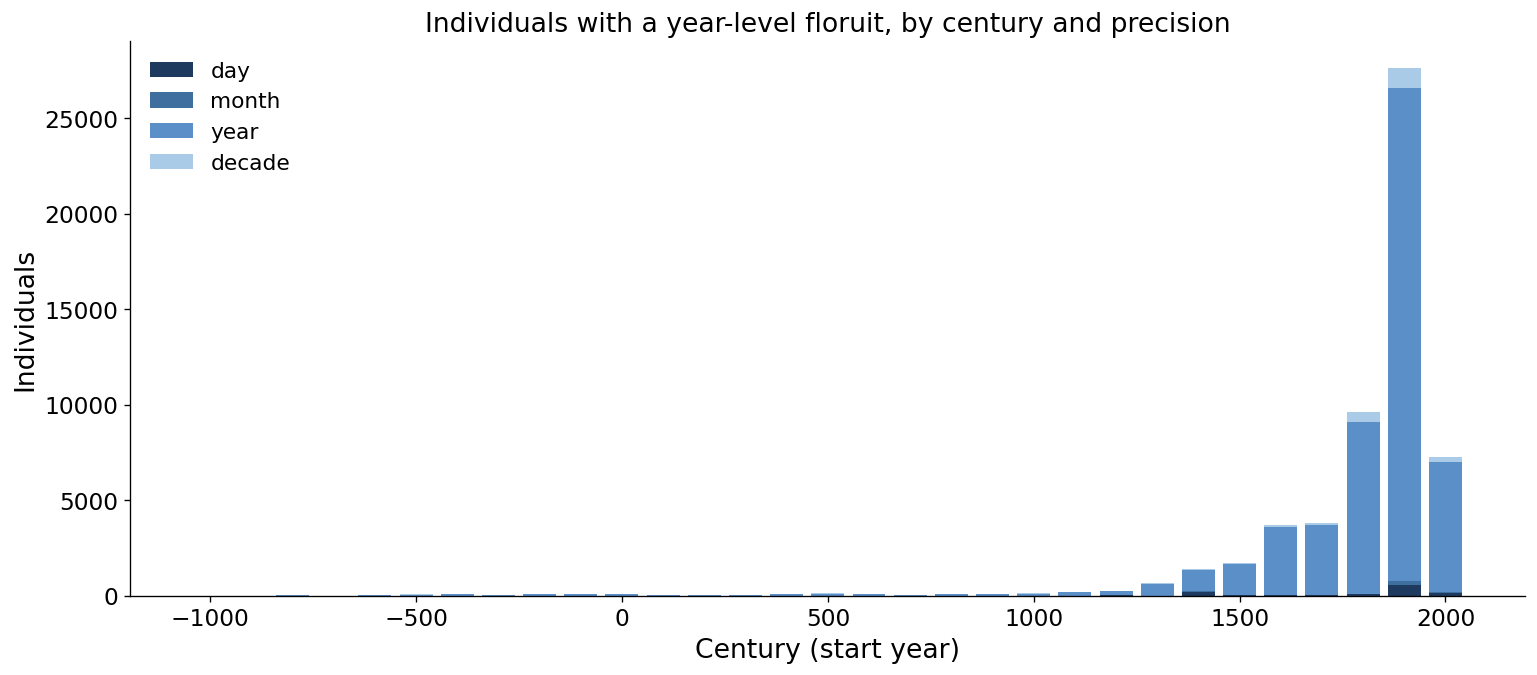

In [8]:
by_century = (
    floruit.filter(pl.col('century_start').is_between(FIRST_CENTURY, LAST_CENTURY))
    .group_by('century_start', 'precision').len()
    .pivot(on='precision', index='century_start', values='len')
    .fill_null(0)
    .sort('century_start')
)
print(f"{floruit.filter(pl.col('century_start') < FIRST_CENTURY).height:,} individuals before {FIRST_CENTURY} left out of the chart")
print(f"{floruit.filter(pl.col('century_start') > LAST_CENTURY).height:,} individuals with a floruit after {LAST_CENTURY + 99} — data errors — left out of the chart")

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
bottom = [0] * by_century.height
for precision in PRECISION_ORDER:
    if precision not in by_century.columns:
        continue
    values = by_century[precision].to_list()
    ax.bar(by_century['century_start'], values, width=80, bottom=bottom, color=PRECISION_COLORS[precision], label=precision)
    bottom = [b + v for b, v in zip(bottom, values)]
ax.set_xlabel('Century (start year)')
ax.set_ylabel('Individuals')
ax.set_title('Individuals with a year-level floruit, by century and precision')
ax.legend()
plt.show()

In [9]:
floruit.group_by('century_start').len().sort('century_start').filter(pl.col('century_start').is_between(FIRST_CENTURY, LAST_CENTURY)).with_columns(
    (pl.col('len') / pl.col('len').sum() * 100).round(1).alias('percent')
)

century_start,len,percent
i64,u32,f64
-1000,3,0.0
-900,4,0.0
-800,10,0.0
-700,7,0.0
-600,40,0.1
-500,65,0.1
-400,89,0.2
-300,61,0.1
-200,82,0.1


## By cross-verified occupation category

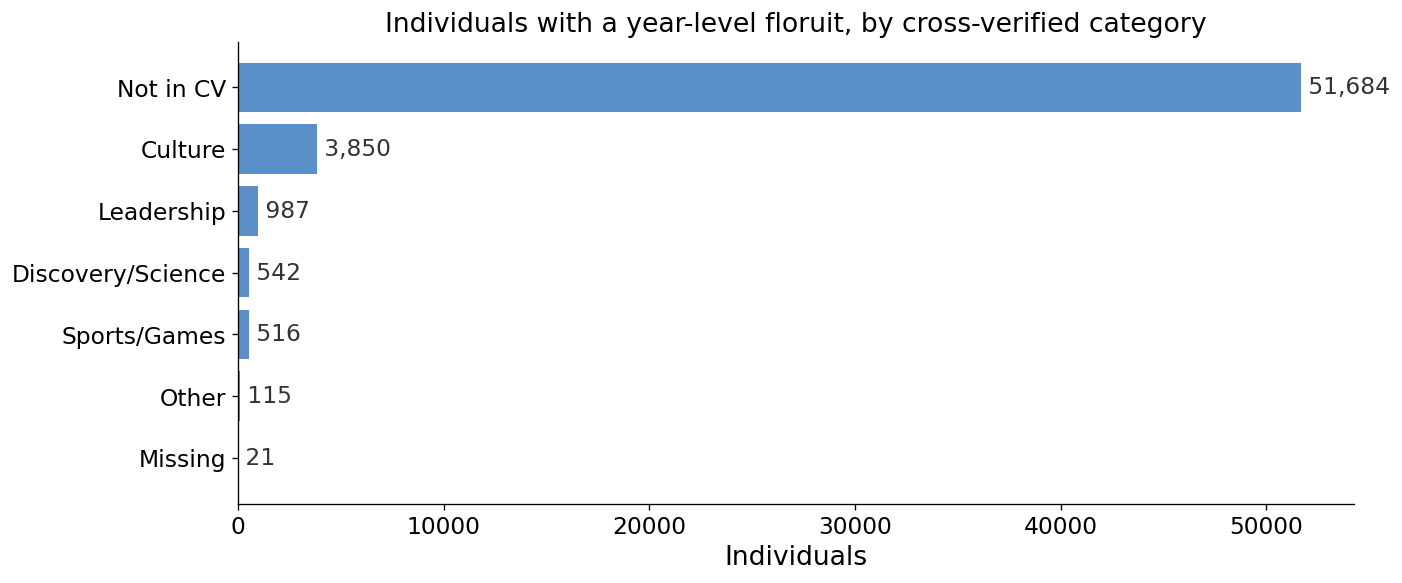

In [10]:
by_category = floruit.group_by('category').len().sort('len')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.barh(by_category['category'], by_category['len'], color=MAIN_COLOR)
for y, value in enumerate(by_category['len']):
    ax.text(value, y, f' {value:,}', va='center', color=TEXT)
ax.set_xlabel('Individuals')
ax.set_title('Individuals with a year-level floruit, by cross-verified category')
plt.show()

## By region

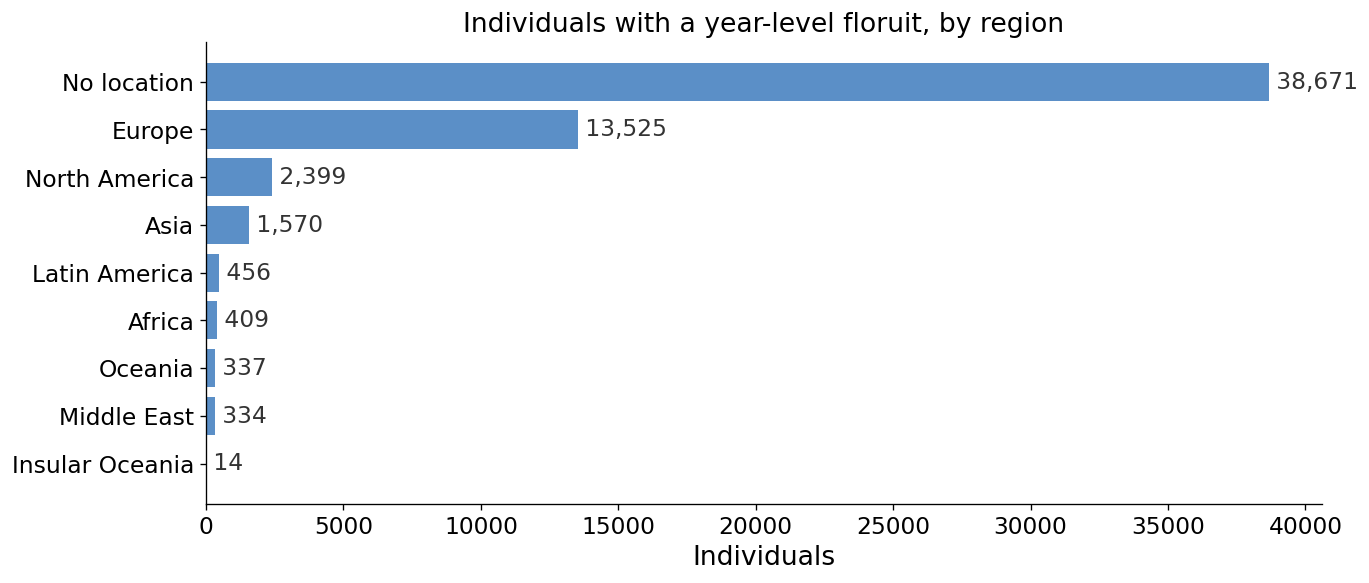

In [11]:
by_region = floruit.group_by('region').len().sort('len')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.barh(by_region['region'], by_region['len'], color=MAIN_COLOR)
for y, value in enumerate(by_region['len']):
    ax.text(value, y, f' {value:,}', va='center', color=TEXT)
ax.set_xlabel('Individuals')
ax.set_title('Individuals with a year-level floruit, by region')
plt.show()

## Category and region by century

In [12]:
(
    floruit.filter(pl.col('century_start').is_between(1000, LAST_CENTURY))
    .group_by('century_start', 'category').len()
    .pivot(on='category', index='century_start', values='len')
    .fill_null(0)
    .sort('century_start')
    .select('century_start', *floruit.group_by('category').len().sort('len', descending=True)['category'])
)

century_start,Not in CV,Culture,Leadership,Discovery/Science,Sports/Games,Other,Missing
i64,u32,u32,u32,u32,u32,u32,u32
1000,95,3,24,3,0,0,0
1100,149,16,32,6,0,0,2
1200,191,27,27,7,0,2,3
1300,530,37,72,8,0,1,0
1400,1214,101,63,6,1,9,0
1500,1512,125,51,20,0,11,2
1600,3464,145,47,43,1,18,2
1700,3591,142,43,25,7,21,1
1800,9089,332,73,91,34,9,1


In [13]:
(
    floruit.filter(pl.col('century_start').is_between(1000, LAST_CENTURY))
    .group_by('century_start', 'region').len()
    .pivot(on='region', index='century_start', values='len')
    .fill_null(0)
    .sort('century_start')
    .select('century_start', *floruit.group_by('region').len().sort('len', descending=True)['region'])
)

century_start,No location,Europe,North America,Asia,Latin America,Africa,Oceania,Middle East,Insular Oceania
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32
1000,110,12,0,0,0,0,0,3,0
1100,169,30,0,2,0,0,0,4,0
1200,191,63,1,0,0,0,0,2,0
1300,571,71,0,3,0,0,0,3,0
1400,1164,214,0,6,0,5,0,5,0
1500,1346,361,1,5,3,1,0,4,0
1600,3243,446,3,13,9,2,0,4,0
1700,3194,578,22,22,10,2,0,2,0
1800,6684,2366,316,153,40,9,49,12,0
